# Pipeline Cálculo Vectorial — Exploración 2026-1

Notebook principal para procesar notas del ciclo 2026-1.  
Ejecutar las celdas en orden.

**Flujo de datos:**
```
Gradescope (corrección)
    ↓  Post Grades to Canvas  ← el docente hace click una vez
Canvas Gradebook (Tareas, APs, EAs, RCs, Exámenes)
    ↓  fetch_canvas_grades_grupo()  ← el pipeline descarga todo
Google Sheets Dashboard
```

**Orden de ejecución:**
1. Imports y configuración
2. Carga del dashboard base (Notas)
3. Descarga de notas desde Canvas API
4. Merge de todas las fuentes
5. Ejecución de cálculos
6. Visualización de resultados
7. Asistencia a Simulacro EP
8. Exportar CSV de salida
9. (Opcional) Actualizar Google Sheets


## 1. Imports y configuración de paths

In [1]:
import sys
import os
import yaml
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Agregar el directorio raíz al path para importar src/
RAIZ = Path().resolve().parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

# Cargar variables de entorno (.env → CANVAS_TOKEN, CANVAS_BASE_URL)
load_dotenv(RAIZ / ".env")

from src.canvas_api import fetch_canvas_grades_grupo, CANVAS_A_PIPELINE
from src.merge import merge_con_fallback, merge_todas_fuentes, reporte_merge
from src.calculos import ejecutar_calculos
from src.reporte import (
    estadisticas_por_seccion,
    alumnos_en_riesgo,
    resumen_curso,
)

# Configuración de paths
CICLO = "2026-1"
DIR_DATA = RAIZ / "data" / CICLO
DIR_PROCESADO = DIR_DATA / "processed"
DIR_OUTPUT = DIR_DATA / "output"

# Cargar configuración del ciclo
with open(RAIZ / "config" / f"{CICLO}.yaml", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

print(f"Ciclo: {CONFIG['ciclo']}")
print(f"Directorio de datos: {DIR_DATA}")
print(f"Secciones auditorio: {CONFIG['secciones']['auditorio']}")
print(f"Secciones aula: {CONFIG['secciones']['aula']}")
print(f"CANVAS_TOKEN cargado: {'✅' if os.getenv('CANVAS_TOKEN') else '❌ — revisar .env'}")

Ciclo: 2026-1
Directorio de datos: C:\Users\jsilvac\calculo-vectorial-pipeline\data\2026-1
Secciones auditorio: [1, 2]
Secciones aula: [11, 12, 13, 14, 21, 22, 23, 24]
CANVAS_TOKEN cargado: ✅


## 2. Carga del dashboard base (Notas)

Lista oficial de alumnos matriculados, descargada desde el Google Sheet 'Notas'.

In [2]:
ARCHIVO_BASE = DIR_DATA / "raw" / "Notas.csv"

df_base = pd.read_csv(
    ARCHIVO_BASE,
    sep=",",
    encoding="utf-8",
    dtype=str,
)

# Limpiar filas completamente vacías
df_base = df_base.dropna(how="all").reset_index(drop=True)

if "Código" in df_base.columns:
    df_base["Código"] = df_base["Código"].str.strip()
if "Correo" in df_base.columns:
    df_base["Correo"] = df_base["Correo"].str.strip()
if "Sección" not in df_base.columns and "Seccion" in df_base.columns:
    df_base["Sección"] = (
        df_base["Seccion"]
        .astype("string")
        .str.extract(r"(\d+(?:[.,]\d+)?)", expand=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
        .astype("Int64")
    )

print(f"Dashboard base cargado: {len(df_base)} alumnos")
print(f"Columnas: {list(df_base.columns)}")
df_base.head()

Dashboard base cargado: 360 alumnos
Columnas: ['Código', 'Apellidos y nombres', 'Correo', 'Carrera', 'Seccion', 'Profesor', 'Vez', 'Veces completas', 'Becado', 'C1V Veces', 'C1V Nota', 'Riesgo Inicial', 'EA1', 'EA2', 'EA3', 'EA4', 'EA5', 'EA6', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'RC-1', 'RC-2', 'RC', 'EP', 'EF', 'SExP', 'ExP', 'SExF', 'ExF', 'BPEA1', 'BPEA2', 'PEA1', 'PEA2', 'PfEA1', 'PfEA2', 'PT1', 'PT2', 'C(TA1)', 'C(TA2)', 'Rezagados', 'NF', 'C_parcial', 'C_final', 'EA', 'TS', 'EP = EF', 'EF necesario', 'Aprobados', 'RETIRADO', 'Sección']


,Código,Apellidos y nombres,Correo,Carrera,Seccion,Profesor,Vez,Veces completas,Becado,C1V Veces,...,NF,C_parcial,C_final,EA,TS,EP = EF,EF necesario,Aprobados,RETIRADO,Sección
0,202410433,"Abril Becerra, Samuel Eduardo",samuel.abril@utec.edu.pe,Ingeniería Mecánica,Teoría 24.00,Alexander Peña,2,NaN,NaN,NaN,...,NaN,"0,00","0,00",#DIV/0!,"0,00",0,30,0,NaN,24
1,202510663,"Aguilar Cardenas, Adriana Linda",adriana.aguilar@utec.edu.pe,Ingeniería Electrónica,Teoría 23.00,Patricia Reynoso,1,NaN,NaN,NaN,...,NaN,"0,00","0,00",#DIV/0!,"0,00",0,30,0,NaN,23
2,202510057,"Aiquipa Meza, José Carlos",jose.aiquipa@utec.edu.pe,Ingeniería Industrial,Teoría 22.00,Alexander Peña,2,NaN,NaN,NaN,...,NaN,"0,00","0,00",#DIV/0!,"0,00",0,30,0,NaN,22
3,202520221,"Alagón Aguilar, Alvaro Mallky",alvaro.alagon@utec.edu.pe,Ciencia de la Computación,Teoría 12.00,Alexander Peña,1,NaN,NaN,NaN,...,NaN,"0,00","0,00",#DIV/0!,"0,00",0,30,0,NaN,12
4,202410244,"Alaluna Paz, Jorge Leonard Rodrigo",jorge.alaluna@utec.edu.pe,Ingeniería Mecánica,Teoría 24.00,Alexander Peña,3,NaN,NaN,NaN,...,NaN,"0,00","0,00",#DIV/0!,"0,00",0,30,0,NaN,24


## 3. Descarga de notas desde Canvas API

Todo viene de Canvas: Tareas, Actividades Previas, EAs, RCs.  
Las EAs se corrigen en Gradescope y el docente hace **Post Grades to Canvas** una vez por evaluación.

- **Auditorios** (secciones 1, 2): Tareas T1–T6 + APs
- **Aulas** (secciones 11–24): EAs 1–6 + RC1, RC2

In [3]:
# --- 3.1 Auditorios: Tareas T1–T6 + Actividades Previas ---
courses_aud = CONFIG["canvas_api"]["courses_auditorio"]
assignments_aud = CONFIG["canvas_api"]["assignments_auditorio"]

print("Descargando notas de auditorios...")
df_canvas_aud = fetch_canvas_grades_grupo(
    courses=courses_aud,
    assignment_names=assignments_aud,
    nombre_a_col=CANVAS_A_PIPELINE,
)
print(f"✅ Auditorios: {len(df_canvas_aud)} alumnos")
print(f"   Columnas descargadas: {[c for c in df_canvas_aud.columns if c not in ['Código','Correo','Sección']]}")
df_canvas_aud.head()

Descargando notas de auditorios...
✅ Auditorios: 359 alumnos
   Columnas descargadas: ['T1', 'AP1V1', 'AP1V2', 'AP2V1', 'AP2V2', 'AP3V1', 'AP3V2', 'T3B', 'AP4V1', 'AP4V2', 'AP5V1', 'AP5V2', 'T4', 'AP6V1', 'AP6V2', 'SExP']


,Código,Correo,Sección,T1,AP1V1,AP1V2,AP2V1,AP2V2,AP3V1,AP3V2,T3B,AP4V1,AP4V2,AP5V1,AP5V2,T4,AP6V1,AP6V2,SExP
0,202410403,anahi.condezo.s@utec.edu.pe,1,20.0,20.0,20.0,20.0,20.0,20.0,20.0,8.0,20.0,20.0,20.0,20.0,20.0,20.0,10.0,NaN
1,202520221,alvaro.alagon@utec.edu.pe,1,20.0,20.0,20.0,20.0,10.0,20.0,20.0,7.0,NaN,NaN,10.0,20.0,20.0,10.0,20.0,20.0
2,202410033,james.alarcon@utec.edu.pe,1,20.0,20.0,20.0,NaN,10.0,10.0,10.0,8.0,20.0,20.0,10.0,20.0,20.0,NaN,NaN,2.5
3,202510175,oriana.alva@utec.edu.pe,1,20.0,10.0,20.0,20.0,10.0,20.0,20.0,7.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,NaN
4,202420132,joel.alva@utec.edu.pe,1,16.0,NaN,NaN,20.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# --- 3.2 Aulas: EAs 1–6 + RC1, RC2 ---
courses_aula = CONFIG["canvas_api"]["courses_aula"]
assignments_aula = CONFIG["canvas_api"]["assignments_aula"]

print("Descargando notas de aulas...")
df_canvas_aula = fetch_canvas_grades_grupo(
    courses=courses_aula,
    assignment_names=assignments_aula,
    nombre_a_col=CANVAS_A_PIPELINE,
)
print(f"✅ Aulas: {len(df_canvas_aula)} alumnos")
print(f"   Columnas descargadas: {[c for c in df_canvas_aula.columns if c not in ['Código','Correo','Sección']]}")
df_canvas_aula.head()

Descargando notas de aulas...
✅ Aulas: 360 alumnos
   Columnas descargadas: ['EA1', 'ExP']


,Código,Correo,Sección,EA1,ExP
0,202410033,james.alarcon@utec.edu.pe,11,9.5,9.0
1,202520008,paolo.aquino@utec.edu.pe,11,14.5,22.0
2,202510471,francisco.artiles@utec.edu.pe,11,3.0,2.5
3,202410710,renzo.ascencio@utec.edu.pe,11,NaN,NaN
4,202420134,grecya.bendezu@utec.edu.pe,11,11.0,12.5


In [5]:
# --- 3.3 Consolidar: un único DataFrame con todos los alumnos ---
# Se agrupa por alumno y se toma el primer valor no nulo por columna.
# Esto combina auditorios (T/AP) y aulas (EA/RC) sin perder columnas.
df_canvas_partes = [
    df.drop(columns=["Sección"], errors="ignore")
    for df in [df_canvas_aud, df_canvas_aula]
    if df is not None and not df.empty
]

if df_canvas_partes:
    df_canvas_all = pd.concat(df_canvas_partes, ignore_index=True)
    df_canvas_all = (
        df_canvas_all
        .groupby(["Código", "Correo"], dropna=False, as_index=False)
        .first()
    )
else:
    df_canvas_all = pd.DataFrame(columns=["Código", "Correo"])

print(f"Canvas consolidado: {len(df_canvas_all)} alumnos")
print(f"Columnas totales: {list(df_canvas_all.columns)}")
df_canvas_all.head()

Canvas consolidado: 360 alumnos
Columnas totales: ['Código', 'Correo', 'T1', 'AP1V1', 'AP1V2', 'AP2V1', 'AP2V2', 'AP3V1', 'AP3V2', 'T3B', 'AP4V1', 'AP4V2', 'AP5V1', 'AP5V2', 'T4', 'AP6V1', 'AP6V2', 'SExP', 'EA1', 'ExP']


,Código,Correo,T1,AP1V1,AP1V2,AP2V1,AP2V2,AP3V1,AP3V2,T3B,AP4V1,AP4V2,AP5V1,AP5V2,T4,AP6V1,AP6V2,SExP,EA1,ExP
0,201820144,diego.rosario@utec.edu.pe,20.0,20.0,20.0,20.0,10.0,20.0,20.0,8.0,20.0,20.0,10.0,20.0,19.0,20.0,20.0,7.0,13.0,11.5
1,201920090,claudio.quinones@utec.edu.pe,20.0,NaN,NaN,20.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN
2,201920135,alejandro.carvallo@utec.edu.pe,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,NaN
3,201920158,luis.ramirez.c@utec.edu.pe,20.0,20.0,20.0,20.0,20.0,20.0,20.0,7.0,20.0,20.0,20.0,20.0,NaN,10.0,20.0,NaN,1.0,NaN
4,202010139,fernando.guillen@utec.edu.pe,18.0,20.0,20.0,NaN,NaN,20.0,20.0,7.0,10.0,20.0,20.0,20.0,17.0,20.0,20.0,NaN,14.0,14.0


## 4. Merge de todas las fuentes

Llave primaria: `Código`. Fallback: `Correo` para alumnos con código especial.

In [34]:
if "df_canvas_all" not in globals():
    raise RuntimeError("Ejecuta primero la celda 3.3 para crear df_canvas_all.")

# Columnas de notas disponibles en Canvas (todo excepto las llaves de identificación)
cols_canvas = [c for c in df_canvas_all.columns if c not in ["Código", "Correo", "Sección"]]

fuentes = {}

if not df_canvas_all.empty:
    fuentes["canvas"] = {
        "df": df_canvas_all,
        "columnas": cols_canvas,
        "sufijo": "_canvas",
    }

# Ejecutar todos los merges
df_merged = merge_todas_fuentes(df_base, fuentes, verbose=True)

# Reporte de cobertura
reporte = reporte_merge(df_merged)
df_merged.shape


--- Mergeando fuente: canvas ---

[MERGE] Columnas: ['T1', 'AP1V1', 'AP1V2', 'AP2V1', 'AP2V2', 'AP3V1', 'AP3V2', 'T3B', 'AP4V1', 'AP4V2', 'AP5V1', 'AP5V2', 'T4', 'AP6V1', 'AP6V2', 'SExP', 'EA1', 'ExP']
  Total alumnos en base : 360
  Match por Código      : 347
  Match por Correo      : 10
  Sin match             : 3

=== REPORTE DE COBERTURA ===
     Evaluación  Con datos  Sin datos (NaN)  Cobertura (%)
        Seccion        360                0          100.0
       Profesor        360                0          100.0
            Vez        360                0          100.0
Veces completas          0              360            0.0
         Becado          0              360            0.0
      C1V Veces          0              360            0.0
       C1V Nota          0              360            0.0
 Riesgo Inicial          0              360            0.0
            EA1        341               19           94.7
            EA2          0              360            0.0
 

(360, 67)

In [45]:
print(df_merged.columns)
print(df_merged["SExP"].unique())  # O el nombre real de la columna del simulacro

Index(['Código', 'Apellidos y nombres', 'Correo', 'Carrera', 'Seccion',
       'Profesor', 'Vez', 'Veces completas', 'Becado', 'C1V Veces', 'C1V Nota',
       'Riesgo Inicial', 'EA1', 'EA2', 'EA3', 'EA4', 'EA5', 'EA6', 'T1', 'T2',
       'T3', 'T4', 'T5', 'T6', 'RC-1', 'RC-2', 'RC', 'EP', 'EF', 'SExP', 'ExP',
       'SExF', 'ExF', 'BPEA1', 'BPEA2', 'PEA1', 'PEA2', 'PfEA1', 'PfEA2',
       'PT1', 'PT2', 'C(TA1)', 'C(TA2)', 'Rezagados', 'NF', 'C_parcial',
       'C_final', 'EA', 'TS', 'EP = EF', 'EF necesario', 'Aprobados',
       'RETIRADO', 'Sección', 'AP1V1', 'AP1V2', 'AP2V1', 'AP2V2', 'AP3V1',
       'AP3V2', 'T3B', 'AP4V1', 'AP4V2', 'AP5V1', 'AP5V2', 'AP6V1', 'AP6V2'],
      dtype='str')
<FloatingArray>
[<NA>, 20.0,  2.5, 10.0,  0.0, 11.0,  9.0,  4.0,  3.0,  7.0,  6.0,  5.0,  2.0,
 13.5,  8.0,  3.5, 11.5,  8.5,  6.5,  1.0, 15.5, 12.0, 13.0, 15.0, 17.0, 16.5]
Length: 26, dtype: Float64


## 5. Ejecución de cálculos

Calcula PT1, PT2, PEA1, PEA2, BPEA1_prov, BPEA2, PfEA1, PfEA2, TA1, TA2, EP, EF, NF.

In [35]:
COLS_AP_BPEA1 = [
    "AP1V1", "AP1V2",
    "AP2V1", "AP2V2",
    "AP3V1", "AP3V2",
    "AP4V1", "AP4V2",
    "AP5V1", "AP5V2",
    "AP6V1", "AP6V2",
]

# Semana 9 tiene 2 videos (AP7V1, AP7V2), resto 1 video cada una
COLS_AP_BPEA2 = ["AP7V1", "AP7V2", "AP8V1", "AP9V1", "AP10V1"]

df_calculado = ejecutar_calculos(
    df_merged,
    CONFIG,
    cols_ap_bpea1=COLS_AP_BPEA1,
    cols_ap_bpea2=COLS_AP_BPEA2,
)

print(f"DataFrame calculado: {df_calculado.shape}")


[CÁLCULOS] Columnas calculadas:
  PT1: 0/360 alumnos con valor
  PT2: 0/360 alumnos con valor
  PEA1: 341/360 alumnos con valor
  PEA2: 0/360 alumnos con valor
  PV1: 328/360 alumnos con valor
  PV2: 0/360 alumnos con valor
  BPEA1_prov: 328/360 alumnos con valor
  BPEA1_final: 335/360 alumnos con valor
  BPEA2: 0/360 alumnos con valor
  PfEA1: 341/360 alumnos con valor
  PfEA2: 0/360 alumnos con valor
  TA1: 0/360 alumnos con valor
  TA2: 0/360 alumnos con valor
  EP: 319/360 alumnos con valor
  EF: 0/360 alumnos con valor
  NF: 0/360 alumnos con valor
DataFrame calculado: (360, 76)


## 6. Visualización de resultados por sección

In [36]:
# Estadísticas globales del curso
df_resumen = resumen_curso(df_calculado)


=== RESUMEN GLOBAL DEL CURSO ===
Evaluación   N  Media  Mediana  Std  Mín  Máx  % >= 10.5
        T1 342  18.16     20.0 2.70  0.0 20.0       97.4
        T4 306  18.44     19.0 1.92  9.0 20.0       99.3
       EA1 341   8.63      8.5 4.72  0.0 20.0       36.1
      PEA1 341   8.84      9.0 4.74  0.0 20.0       36.1
     PfEA1 341  10.30     10.0 5.09  0.0 22.0       49.6
        EP 319  12.12     12.0 5.32  0.0 20.0       61.1


[AVISO] No hay datos no nulos para 'NF' por sección.

Estadísticas de NF por sección:


,Sección,N,Media,Mediana,Std,Mín,Máx,% >= 10.5


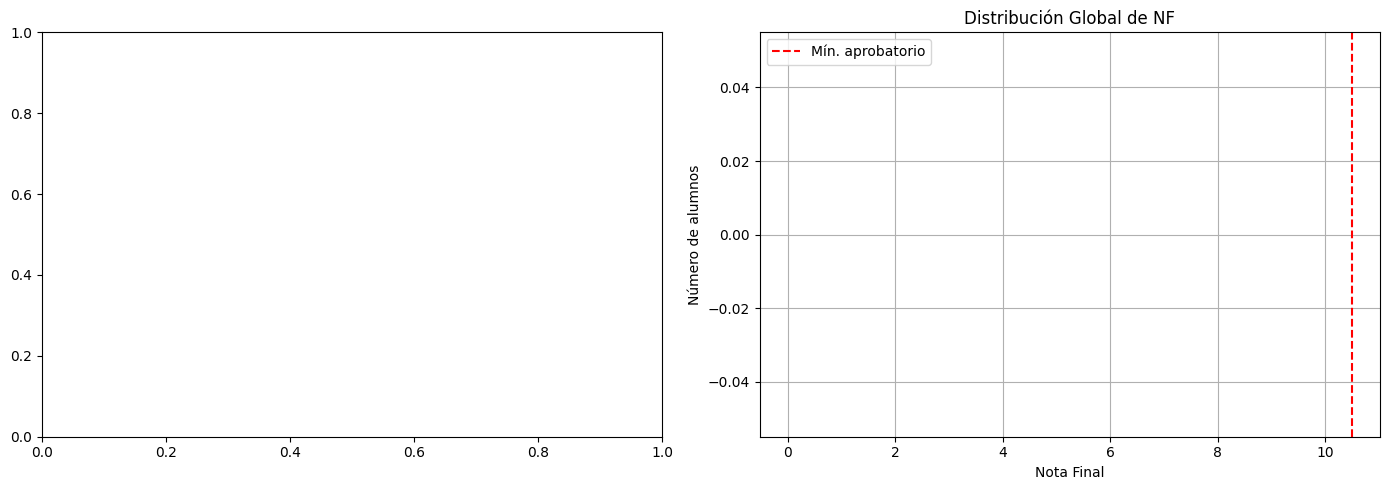

In [38]:
# Estadísticas por sección para NF (o cualquier columna calculada)
if "NF" in df_calculado.columns:
    df_stats_seccion = estadisticas_por_seccion(df_calculado, "NF")
    print("\nEstadísticas de NF por sección:")
    display(df_stats_seccion)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot por sección
    df_plot = df_calculado[["Sección", "NF"]].dropna()
    if not df_plot.empty:
        df_plot["Sección"] = df_plot["Sección"].astype(str)
        sns.boxplot(data=df_plot, x="Sección", y="NF", ax=axes[0], palette="muted")
        axes[0].set_title("Distribución de NF por Sección")
        axes[0].set_ylabel("Nota Final")
        axes[0].axhline(10.5, color="red", linestyle="--", label="Mín. aprobatorio")
        axes[0].legend()

    # Histograma de NF global
    df_calculado["NF"].dropna().hist(
        bins=20, ax=axes[1], color="steelblue", edgecolor="white"
    )
    axes[1].axvline(10.5, color="red", linestyle="--", label="Mín. aprobatorio")
    axes[1].set_title("Distribución Global de NF")
    axes[1].set_xlabel("Nota Final")
    axes[1].set_ylabel("Número de alumnos")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(DIR_OUTPUT / "distribucion_NF.png", dpi=150, bbox_inches="tight")
    plt.show()

In [39]:
# Alumnos en riesgo (NF proyectada < 10.5)
df_riesgo = alumnos_en_riesgo(df_calculado, umbral=10.5)
if not df_riesgo.empty:
    display(df_riesgo)


[RIESGO] Alumnos con NF < 10.5: 0/0 (0%)


## 7. Asistencia a Simulacro EP

Resumen r?pido de cu?ntos alumnos no tienen nota en `SExP` (`NaN`), como aproximaci?n a no presentados.


In [ ]:
col_asistencia_sexp = "SExP_raw" if "SExP_raw" in df_calculado.columns else "SExP"

if col_asistencia_sexp not in df_calculado.columns:
    raise KeyError("No existe una columna SExP/SExP_raw en df_calculado.")

n_total = len(df_calculado)
n_no_presentados_sexp = df_calculado[col_asistencia_sexp].isna().sum()
pct_no_presentados_sexp = (n_no_presentados_sexp / n_total * 100) if n_total else 0

print(
    f"Alumnos con {col_asistencia_sexp} en NaN: "
    f"{n_no_presentados_sexp}/{n_total} ({pct_no_presentados_sexp:.1f}%)"
)

display(
    pd.DataFrame([
        {
            "indicador": f"{col_asistencia_sexp} en NaN",
            "alumnos": n_no_presentados_sexp,
            "total": n_total,
            "porcentaje": round(pct_no_presentados_sexp, 1),
        }
    ])
)


## 8. Exportar CSV de salida

Guarda el DataFrame final como respaldo local en `data/2026-1/output/`.

In [40]:
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

ARCHIVO_SALIDA = DIR_OUTPUT / "notas_calculadas_2026-1.csv"
# Seleccionar solo columnas limpias para exportar
columnas_limpias = [col for col in df_calculado.columns if not col.endswith('_raw')]
df_calculado[columnas_limpias].to_csv(ARCHIVO_SALIDA, index=False, encoding="utf-8")
print(f'✅ Notas exportadas: {ARCHIVO_SALIDA}')
print(f'   Filas: {len(df_calculado)}, Columnas exportadas: {len(columnas_limpias)}')

✅ Notas exportadas: C:\Users\jsilvac\calculo-vectorial-pipeline\data\2026-1\output\notas_calculadas_2026-1.csv
   Filas: 360, Columnas exportadas: 74


## 9. (Opcional) Actualizar Google Sheets

⚙️ Requiere:
- Archivo `credentials/service_account.json`
- Sheet ID configurado en `config/2026-1.yaml`
- Sheet compartido con el email de la Service Account

In [ ]:
# Descoentar para ejecutar la actualización de Google Sheet

from src.gdrive import conectar_gspread, escribir_columnas_notas, escribir_formativa

CREDENTIALS = RAIZ / "credentials" / "service_account.json"
SHEET_ID = CONFIG["dashboard"]["sheet_id"]

gc = conectar_gspread(CREDENTIALS)


columnas_a_escribir = [
    "T1",
    "EA1","EP","SExP", "ExP",
]

#columnas_a_escribir = [
#    "T1", "T3A",
#    "EA1",
#    "PT1", "PEA1", "BPEA1_prov", "PfEA1",
#    "TA1", "EP", "EF", "NF",]


escribir_columnas_notas(
    sheet_id=SHEET_ID,
    df=df_calculado,
    columnas=columnas_a_escribir,
    gc=gc,
)

#escribir_formativa(
#    sheet_id=SHEET_ID,
#    df_formativa=df_calculado,
#    gc=gc,
#)
print("(Celda de actualización de Google Sheets — descomentar para usar)")